# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [5]:
# untuk plot Q-Q
import scipy.stats as stats

In [6]:
df_california = pd.read_csv('california_dataset.csv')

In [9]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

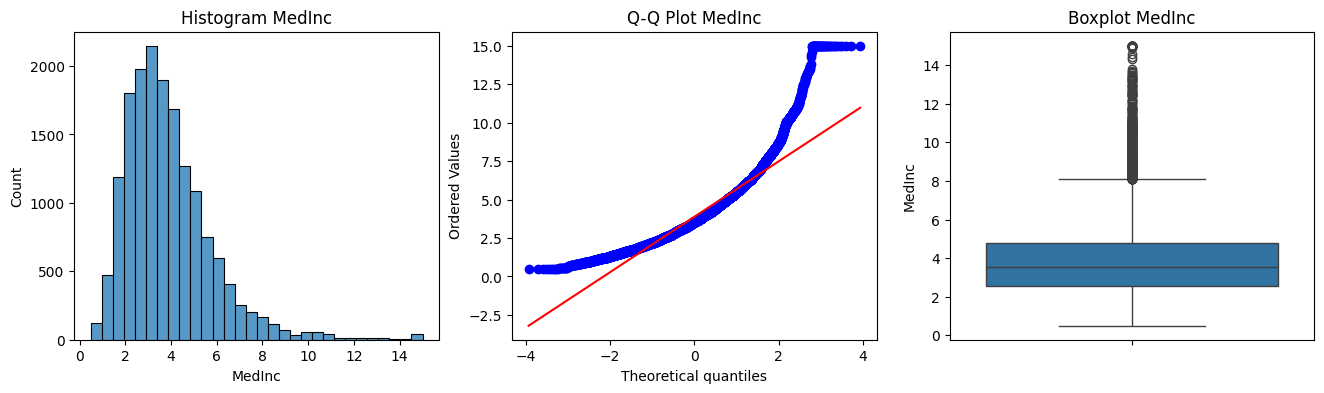

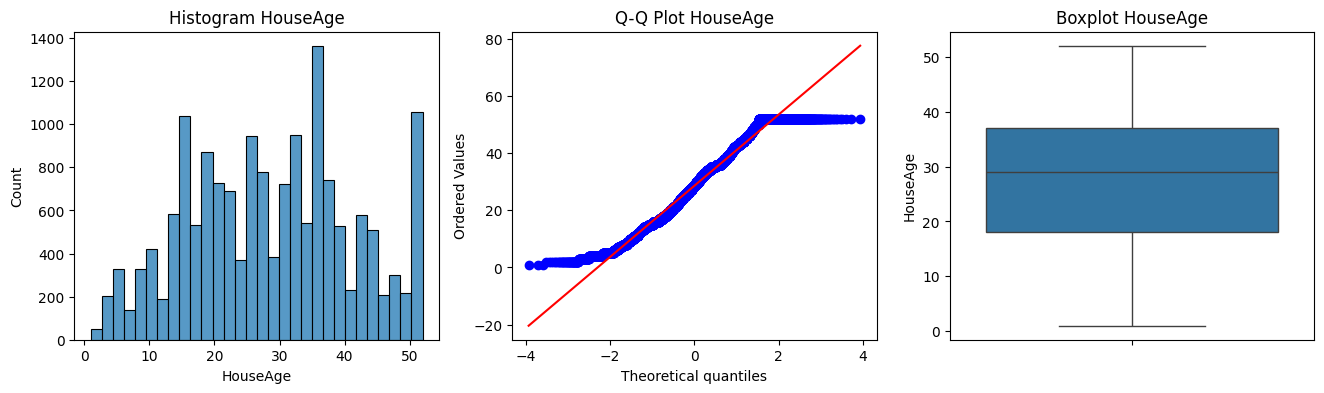

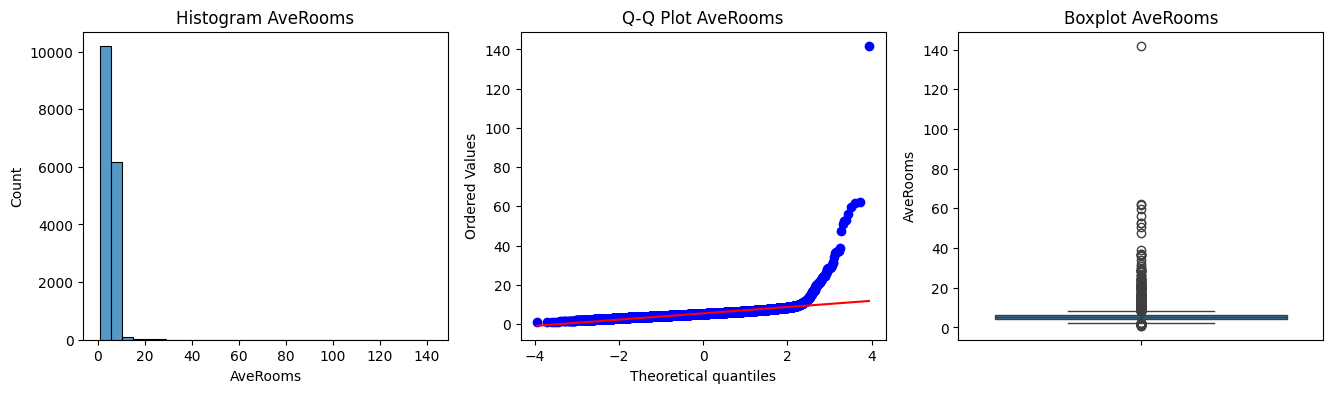

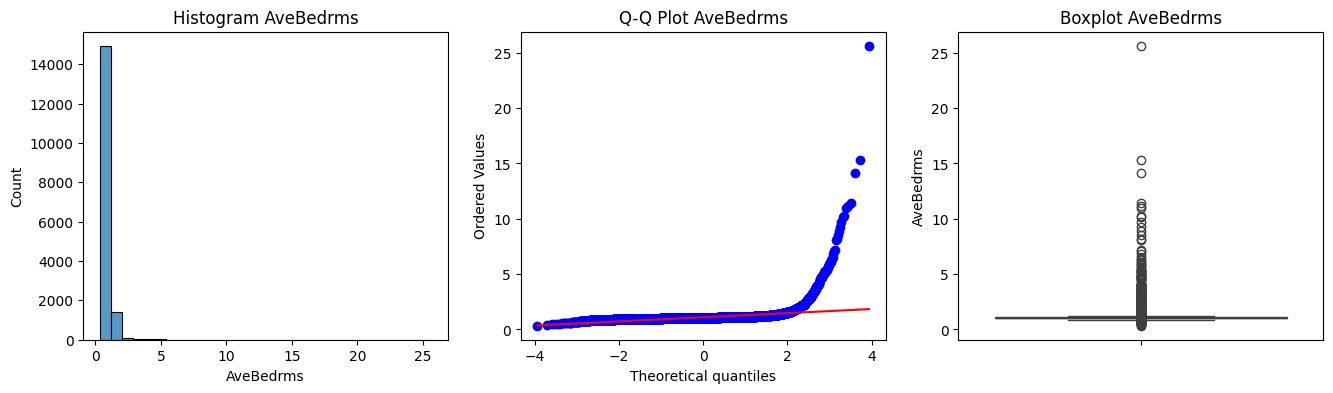

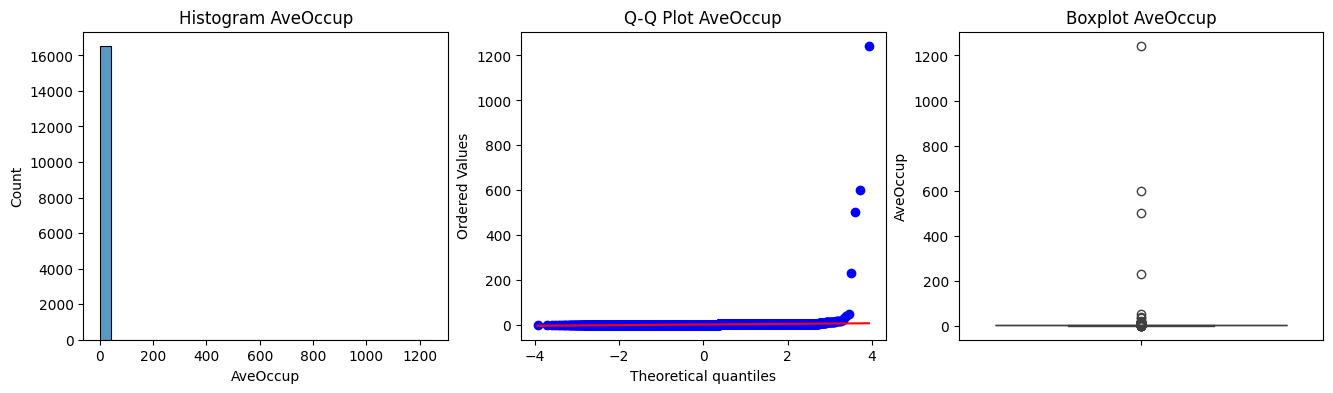

In [ ]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek
train_clfr, test_clfr = train_test_split(df_california, test_size=0.2, random_state=42)

kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

def check_plot(df, variable):
    plt.figure(figsize=(16, 4))
    
    # Histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title(f'Histogram {variable}')

    # Q-Q Plot
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot {variable}')

    # Boxplot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title(f'Boxplot {variable}')

    plt.show()

# 4. Looping untuk melihat distribusi tiap kolom
for col in kolom_kolom:
    check_plot(train_clfr, col)

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

Distribusi MedInc SETELAH Handling Outlier:


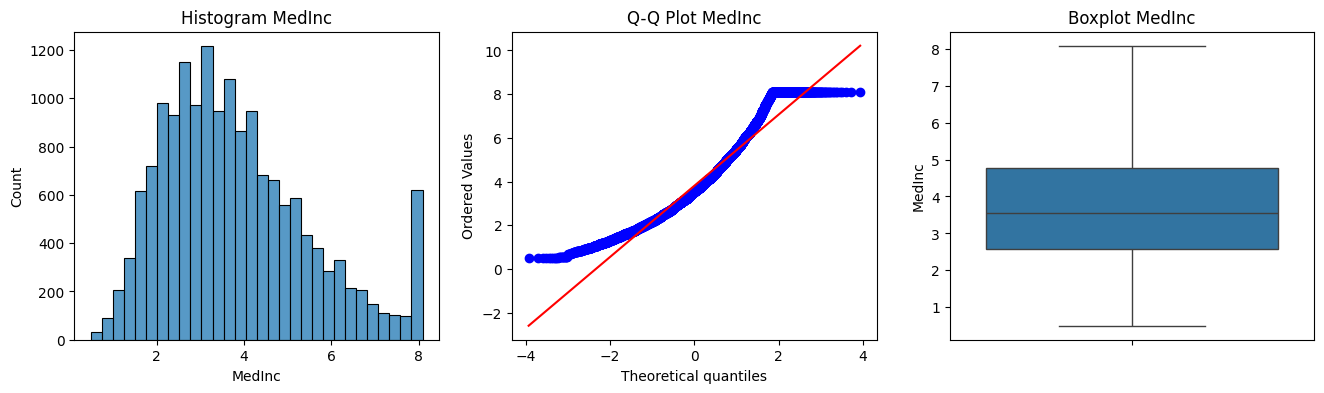

In [ ]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali
# kolom MedInc untuk di-handling menggunakan IQR
def find_outlier_boundary(df, variable):

    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)
    lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
    upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)
    return upper_boundary, lower_boundary

MedInc_upper, MedInc_lower = find_outlier_boundary(train_clfr, 'MedInc')

train_clfr['MedInc'] = np.where(
    train_clfr['MedInc'] > MedInc_upper, MedInc_upper,
    np.where(train_clfr['MedInc'] < MedInc_lower, MedInc_lower, train_clfr['MedInc'])
)

print("Distribusi MedInc SETELAH Handling Outlier:")
check_plot(train_clfr, 'MedInc')

In [ ]:
# Melakukan loop untuk mengecek distribusi tiap kolom


# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [14]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [12]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [ ]:
#Tulis jawaban missing value handling kolom Headquarters disini
train_company, test_company = train_test_split(df_company, test_size=0.2, random_state=42)

missing_count = len(train_company[train_company['Headquarters'] == '-1'])
total_data = len(train_company)
missing_percentage = 100 * missing_count / total_data

print(f"Persentase Missing Value di kolom Headquarters: {missing_percentage:.2f}%")

if missing_percentage > 20:
    print("Hasil: Diatas 20%, maka kolom Headquarters di DROP.")
    train_company = train_company.drop(columns=['Headquarters'])
    test_company = test_company.drop(columns=['Headquarters'])
else:
    print("Hasil: Dibawah 20%, maka handling menggunakan MODUS.")
    modus_hq = train_company[train_company['Headquarters'] != '-1']['Headquarters'].mode()[0]
    
    train_company['Headquarters'] = train_company['Headquarters'].replace('-1', modus_hq)
    test_company['Headquarters'] = test_company['Headquarters'].replace('-1', modus_hq)
    
    print(f"Nilai '-1' berhasil diganti dengan modus: {modus_hq}")

Persentase Missing Value di kolom Headquarters: 4.47%
Hasil: Dibawah 20%, maka handling menggunakan MODUS.
Nilai '-1' berhasil diganti dengan modus: New York, NY


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [17]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

In [18]:
#Splitting terlebih dahulu
train_churn, test_churn = train_test_split(df_churn, test_size=0.2, random_state=42)

## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [19]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cols_to_encode = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 
                  'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

for col in cols_to_encode:
    df_churn[col] = df_churn[col].replace({'No internet service': 'No', 'No phone service': 'No'})

for col in cols_to_encode:
    train_churn[col] = le.fit_transform(train_churn[col])
    test_churn[col] = le.transform(test_churn[col])

print("Hasil Value Counts setelah Label Encoding (Contoh: StreamingMovies):")
print(train_churn['StreamingMovies'].value_counts())
train_churn[cols_to_encode].head()

Hasil Value Counts setelah Label Encoding (Contoh: StreamingMovies):
StreamingMovies
0    2223
2    2197
1    1214
Name: count, dtype: int64


,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
2142,2,0,0,2,0,2,0
1623,2,2,0,0,2,0,2
6074,0,0,0,0,0,0,1
1362,0,0,0,0,0,0,0
6754,0,0,2,0,2,2,2


## Selesai :)